In [1]:
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df=load_iris()
x=df.data
y=df.target

In [5]:
scaler=StandardScaler()
xs=scaler.fit_transform(x)

<Axes: >

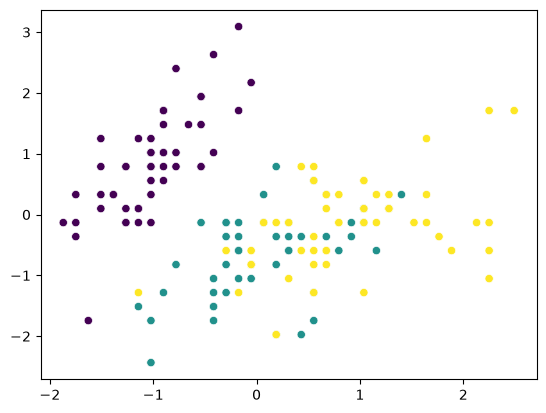

In [6]:
sns.scatterplot(x=xs[:,0],y=xs[:,1],c=y)

In [8]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.8,min_samples=5)
labels=dbscan.fit_predict(xs)

<Axes: >

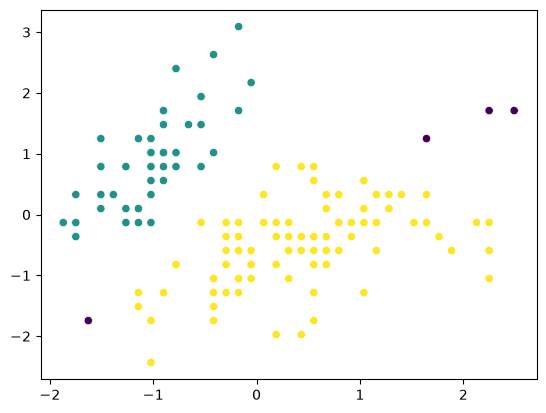

In [9]:
sns.scatterplot(x=xs[:,0],y=xs[:,1],c=labels)

In [28]:
 #DBSCAN with non linear data
from sklearn.datasets import make_moons
x,y=make_moons(n_samples=300,noise=0.05,random_state=10)

In [29]:
scaler=StandardScaler()
x_s=scaler.fit_transform(x)

<Axes: >

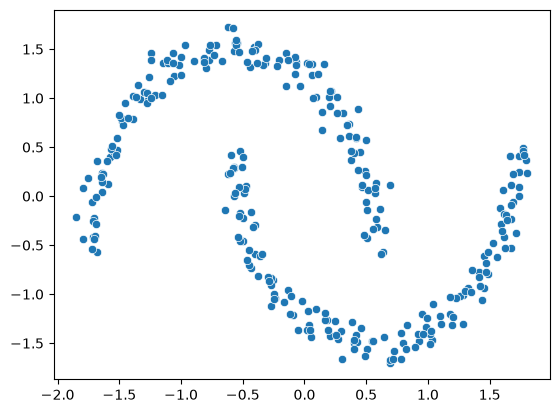

In [30]:
sns.scatterplot(x=x_s[:,0],y=x_s[:,1])

In [31]:
#kmeans
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,21):
    kms=KMeans(n_clusters=k)
    labels=kms.fit_predict(x_s)
    wcss.append(kms.inertia_)
    

C:\Users\dille\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\dille\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\dille\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\dille\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

In [32]:
knee=KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")
k=knee.knee
print(k)

5


C:\Users\dille\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


<Axes: >

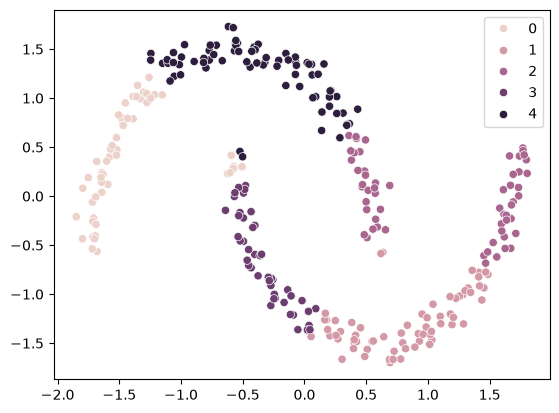

In [33]:
km=KMeans(n_clusters=k)
labels=km.fit_predict(x_s)
sns.scatterplot(x=x_s[:,0],y=x_s[:,1],hue=labels)

<Axes: >

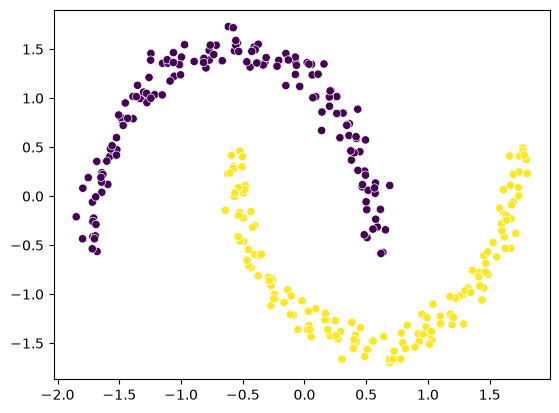

In [35]:
dbscan=DBSCAN(eps=0.5,min_samples=5)
labels=dbscan.fit_predict(x_s)
sns.scatterplot(x=x_s[:,0],y=x_s[:,1],c=labels)